<a href="https://colab.research.google.com/github/winpeperk/dls/blob/main/week_10_AE_VAE/Homework/hw_7_autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

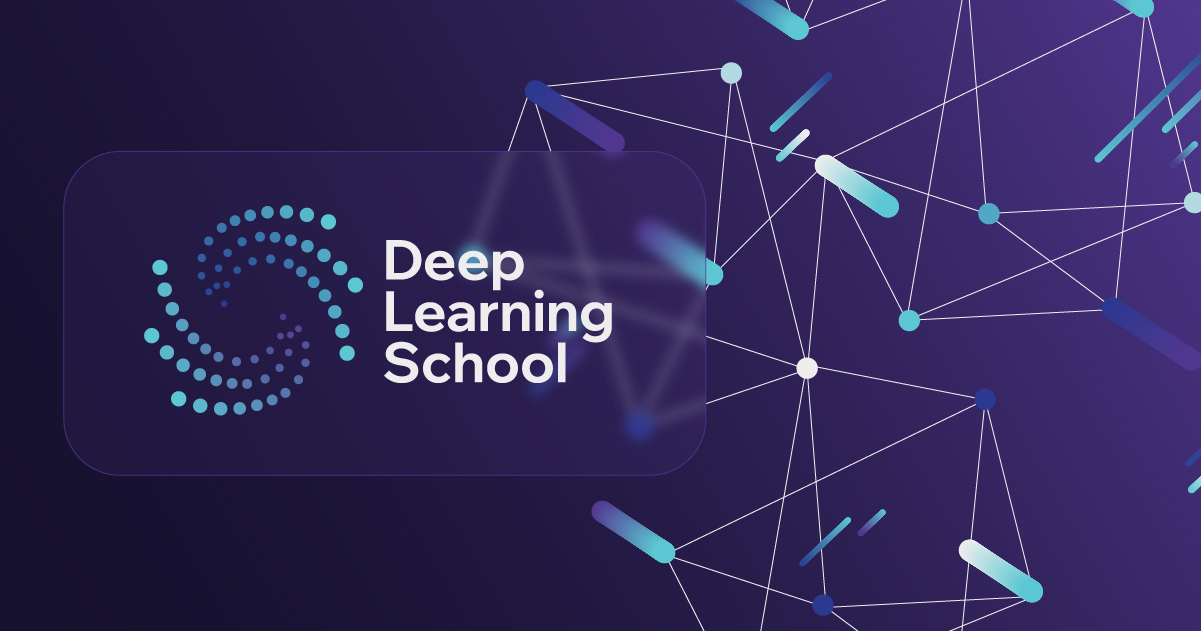


# Домашнее задание "Варианционные автоэнкодеры"

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [1]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import os
import pandas as pd
import skimage.io
from skimage.transform import resize
import seaborn as sns
sns.set_style('darkgrid')

import imageio
from PIL import Image
import kagglehub
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

%matplotlib inline

cpu


В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [2]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Path to dataset files: /kaggle/input/lfw-dataset


In [3]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Using Colab cache for faster access to the 'lfw-attributes' dataset.
Path to dataset files: /kaggle/input/lfw-attributes


In [4]:
DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

In [5]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id, 'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs, photo_ids, on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person",'imagenum'],axis=1)

    return images, attrs

In [6]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset()


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [7]:
from sklearn.model_selection import train_test_split

train_img, val_img, train_attrs, val_attrs = train_test_split(images, attrs, train_size=0.9)
train_img = torch.FloatTensor(train_img) / 255
val_img = torch.FloatTensor(val_img) / 255

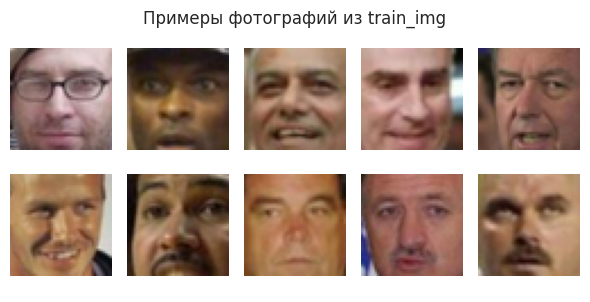

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))
plt.title('Примеры фотографий из train_img')
plt.axis("off")
for i, img in enumerate(train_img[:10]):
  plt.subplot(2, 5, i + 1)
  plt.imshow(img)
  plt.axis("off")

plt.tight_layout()
plt.show()

## 1.2. Архитектура модели (2 балла)


В этом разделе вы напишите и обучите обычный автоэнкодер.



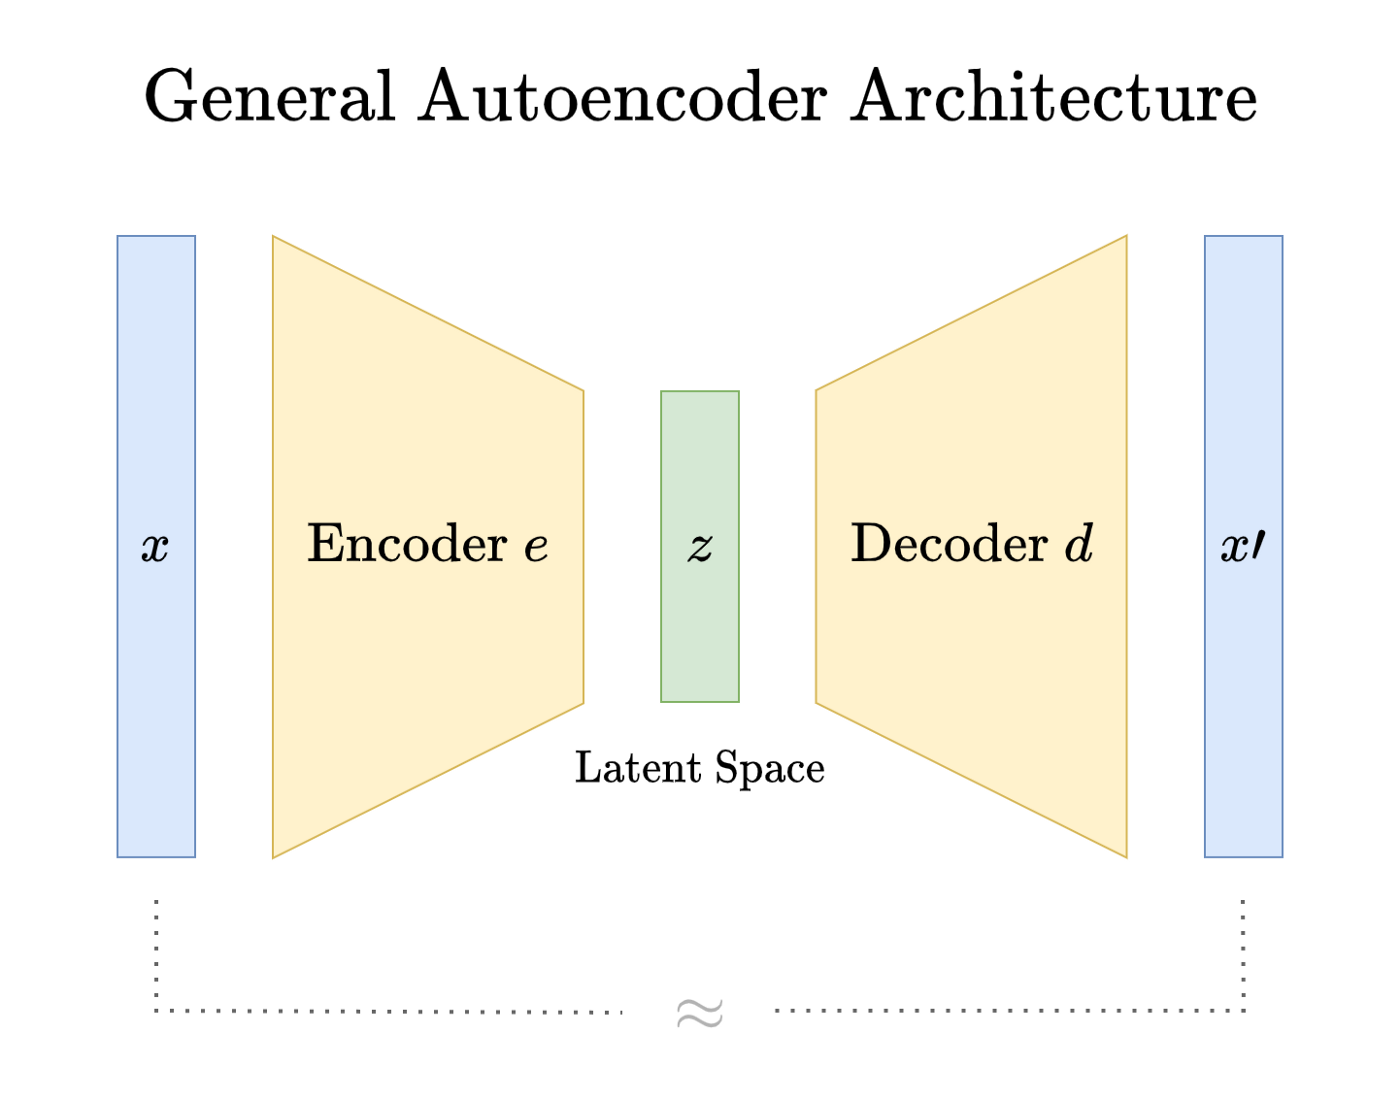

In [8]:
# выберите размер латентного вектора
dim_code = 128

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [17]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),   # 45 -> 23
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 23 -> 12
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), # 12 -> 6
            nn.ReLU()
        )

        self.to_latent = nn.Sequential(
            nn.Flatten(), # 128 * 6 * 6
            nn.Linear(128 * 6 * 6, dim_code)
        )

        self.from_latent = nn.Linear(dim_code, 128 * 6 * 6)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), # 6 -> 12
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1), # 12 -> 23
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1),  # 23 -> 45
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        latent_code = self.to_latent(x)
        x = self.from_latent(latent_code)
        x = x.view(-1, 128, 6, 6)
        reconstructed = self.decoder(x)

        return reconstructed, latent_code

In [18]:
train_loader = torch.utils.data.DataLoader(train_img.permute(0,3,1,2), batch_size=5)
val_loader = torch.utils.data.DataLoader(val_img.permute(0,3,1,2), batch_size=5)

criterion = F.mse_loss
model = Autoencoder().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

In [9]:
def train_one_epoch(train_loader, model, optimizer, criterion):
    model.train()
    train_losses_per_epoch = []
    for i, X_batch in enumerate(train_loader):
      X_batch = X_batch.to(device)
      optimizer.zero_grad()
      reconstructed, latent_code = model(X_batch)
      loss = criterion(reconstructed, X_batch)
      loss.backward()
      optimizer.step()
      train_losses_per_epoch.append(loss.item())

    return np.mean(train_losses_per_epoch)

def val_one_epoch(val_loader, model, criterion):
    model.eval()
    val_losses_per_epoch = []
    with torch.no_grad():
      for X_batch in val_loader:
        X_batch = X_batch.to(device)
        reconstructed, latent_code = model(X_batch)
        loss = criterion(reconstructed, X_batch)
        val_losses_per_epoch.append(loss.item())

    return np.mean(val_losses_per_epoch)

def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(8, 5))

    plt.plot(train_losses, label="train loss")
    plt.plot(val_losses, label="val loss")

    plt.xlabel("Epoch"), plt.ylabel("Loss")
    plt.title("Losses")
    plt.legend()
    plt.show()

def show_reconstructions(model, val_loader, device, n_images=5):
    model.eval()

    with torch.no_grad():
      X_batch = next(iter(val_loader))
      reconstructed, latent_code = model(X_batch.to(device))

    X_batch  = X_batch.to('cpu')
    reconstructed = reconstructed.to('cpu')
    plt.figure(figsize=(n_images * 2, 5))
    for i in range(n_images):
        # оригинал
        plt.subplot(2, n_images, i + 1)
        img = X_batch[i].permute(1, 2, 0)
        plt.imshow(img)
        plt.title("Original")
        plt.axis("off")

        # реконструкция
        plt.subplot(2, n_images, i + 1 + n_images)
        img_rec = reconstructed[i].permute(1, 2, 0)
        plt.imshow(img_rec)
        plt.title("Reconstructed")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

def train(model, optimizer, criterion, train_loader, val_loader, max_epochs=20):
    train_losses = []
    val_losses = []
    for epoch in tqdm(range(max_epochs)):
      mean_train_losses_per_epoch = train_one_epoch(train_loader, model, optimizer, criterion)
      train_losses.append(mean_train_losses_per_epoch)

      mean_val_losses_per_epoch = val_one_epoch(val_loader, model, criterion)
      val_losses.append(mean_val_losses_per_epoch)

      print(
          f"Epoch {epoch + 1}/{max_epochs} | "
          f"train loss: {mean_train_losses_per_epoch:.4f} | "
          f"val loss: {mean_val_losses_per_epoch:.4f}"
      )

      if (epoch + 1) % 5 == 0:
          show_reconstructions(model, val_loader, device)

    plot_losses(train_losses, val_losses)

    return train_losses, val_losses

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1/20 | train loss: 0.0080 | val loss: 0.0047
Epoch 2/20 | train loss: 0.0038 | val loss: 0.0035
Epoch 3/20 | train loss: 0.0029 | val loss: 0.0028
Epoch 4/20 | train loss: 0.0026 | val loss: 0.0025
Epoch 5/20 | train loss: 0.0023 | val loss: 0.0024


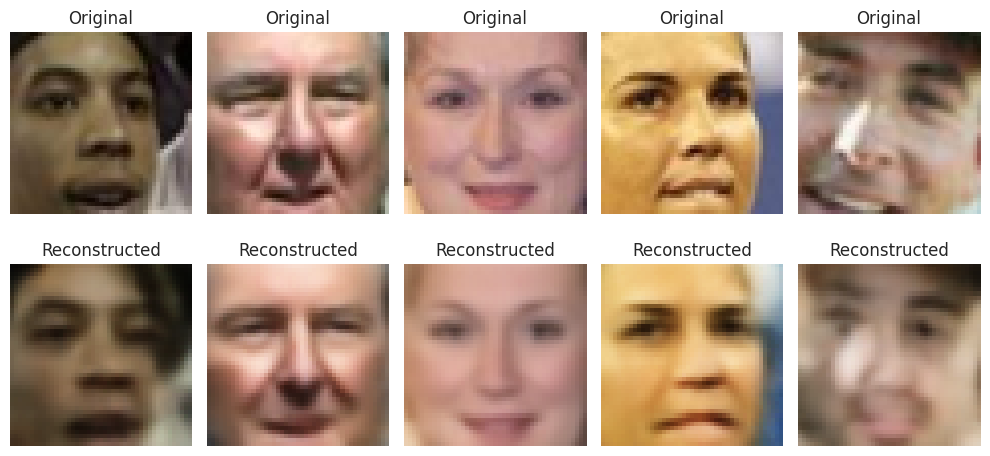

Epoch 6/20 | train loss: 0.0022 | val loss: 0.0023
Epoch 7/20 | train loss: 0.0021 | val loss: 0.0023
Epoch 8/20 | train loss: 0.0020 | val loss: 0.0023
Epoch 9/20 | train loss: 0.0020 | val loss: 0.0023
Epoch 10/20 | train loss: 0.0020 | val loss: 0.0022


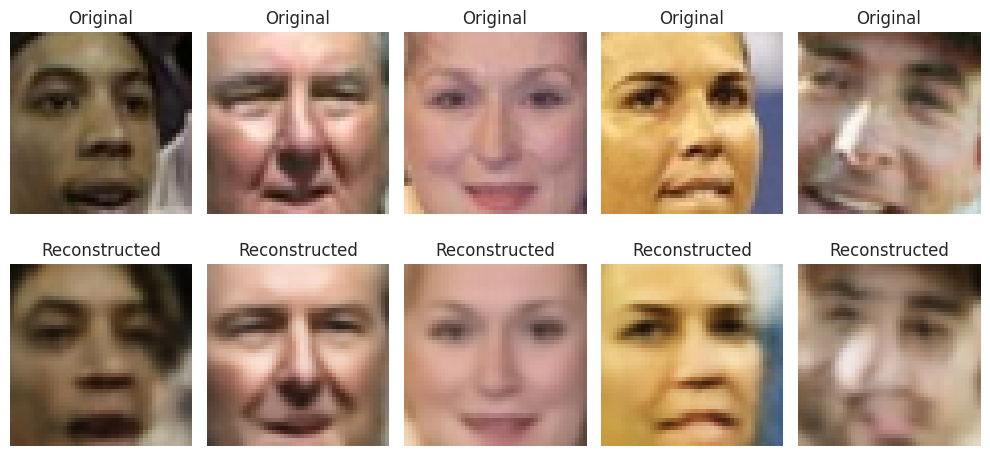

Epoch 11/20 | train loss: 0.0019 | val loss: 0.0022
Epoch 12/20 | train loss: 0.0019 | val loss: 0.0022
Epoch 13/20 | train loss: 0.0019 | val loss: 0.0023
Epoch 14/20 | train loss: 0.0018 | val loss: 0.0022
Epoch 15/20 | train loss: 0.0018 | val loss: 0.0022


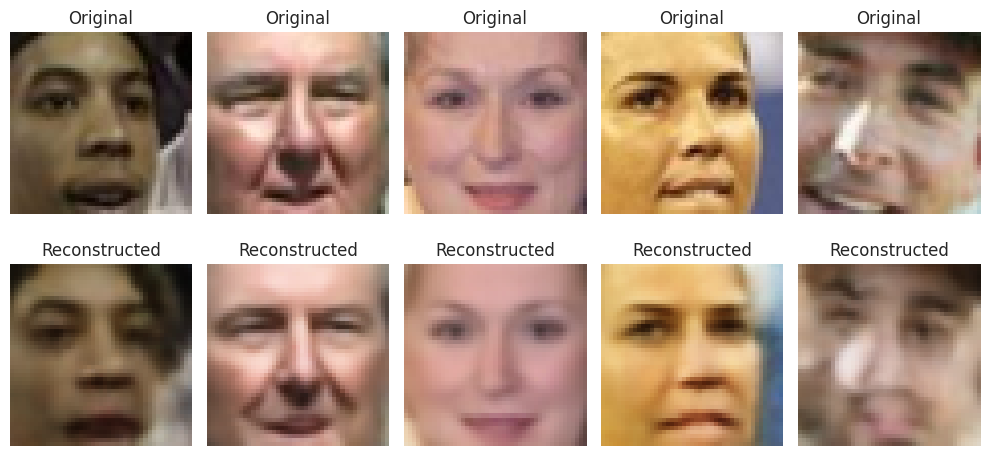

Epoch 16/20 | train loss: 0.0018 | val loss: 0.0022
Epoch 17/20 | train loss: 0.0018 | val loss: 0.0021
Epoch 18/20 | train loss: 0.0018 | val loss: 0.0021
Epoch 19/20 | train loss: 0.0017 | val loss: 0.0021
Epoch 20/20 | train loss: 0.0017 | val loss: 0.0022


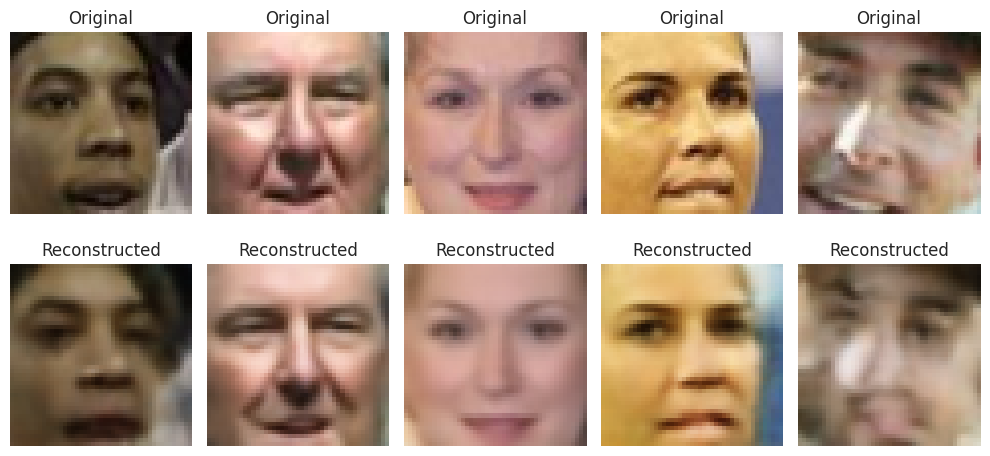

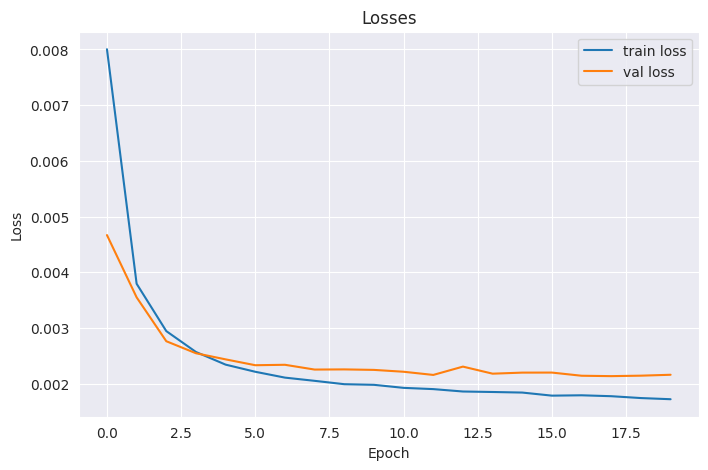

In [ ]:
train_losses, val_losses = train(model, optimizer, criterion, train_loader, val_loader)

Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

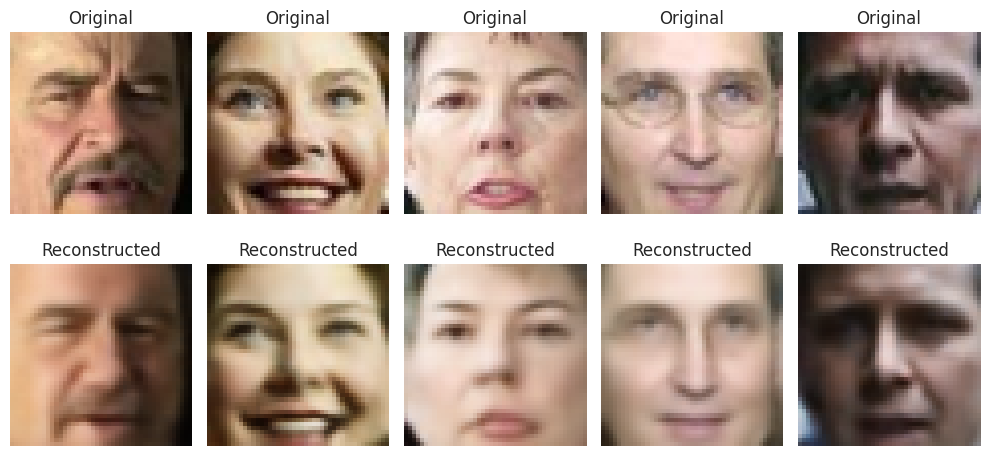

In [ ]:
from itertools import islice # для отрисовки 2-го батча (1-й был до этого)

show_reconstructions(model, islice(val_loader, 1, None), device)

Что вы можете сказать про результат?

Вывод: В целом, автоэнкодер реконструирует фотографии неплохо, есть проблемы с их четкостью. Особенно искажается лицо, если оно под наклоном (мы можем это наблюдать во время обучения на 5-ой фотографии).

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

Чтобы распределение латентных векторов было похоже на реальные, посчитаем `mean` и `std` по латентным векторам из датасета. Затем случайный вектор умножим на `std` и прибавим `mean`, чтобы его распределение стало ближе к распределению лиц людей.

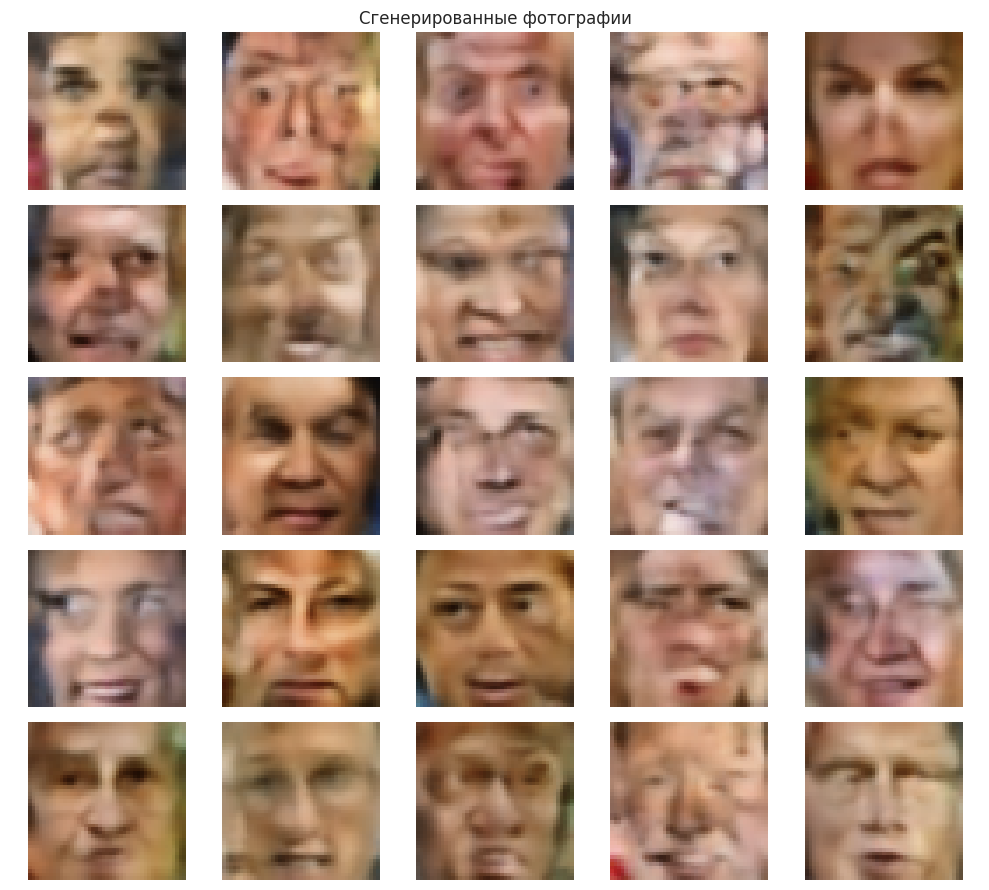

In [ ]:
latents = []
n_images = 25

model.eval()
with torch.no_grad():
    for X_batch in val_loader:
        X_batch = X_batch.to(device)
        reconstructed, latent_code = model(X_batch)
        latents.append(latent_code.cpu())

latents = torch.cat(latents, dim=0)
mean = latents.mean(dim=0) # mean по каждой координате в латентном векторе
std = latents.std(dim=0) # аналогично std

z_new = mean + std * torch.randn(n_images, dim_code)

model.eval()
with torch.no_grad():
    x = model.from_latent(z_new.to(device))
    x = x.view(-1, 128, 6, 6)
    generated = model.decoder(x).cpu()

plt.figure(figsize=(10, 9))
plt.title('Сгенерированные фотографии')
plt.axis("off")
for i in range(n_images):
    plt.subplot(5, 5, i + 1)
    img = generated[i].permute(1, 2, 0)
    img = torch.clamp(img, 0, 1)
    plt.imshow(img)
    plt.axis("off")
plt.tight_layout()
plt.show()

Вывод: наш автоэнкодер плохо генерирует лица людей, много искажений.

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

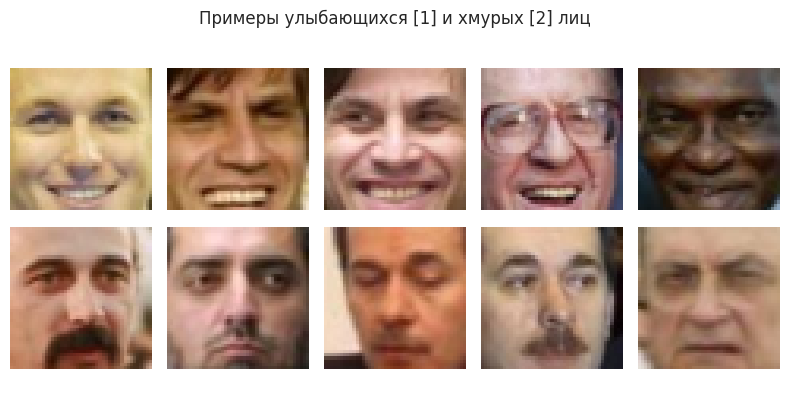

In [ ]:
indx = attrs.loc[attrs['Smiling'] >= 0.9].index
smiling_img = images[indx]

indx = attrs.loc[(attrs['Frowning'] >= 0.95) & (attrs['Teeth Not Visible'] >= 0.9)].index
frowning_img = images[indx]

plt.figure(figsize=(8, 4))
plt.suptitle('Примеры улыбающихся [1] и хмурых [2] лиц')
plt.axis("off")
for i, img in enumerate(smiling_img[:5]):
  plt.subplot(2, 5, i + 1)
  plt.imshow(img)
  plt.axis("off")

for i, img in enumerate(frowning_img[:5]):
  plt.subplot(2, 5, i + 6)
  plt.imshow(img)
  plt.axis("off")

plt.tight_layout()
plt.show()

Посчитаем средние латентные вектора улыбающихся и хмурых людей.

In [ ]:
latents = []

smiling_img = torch.FloatTensor(smiling_img).permute(0, 3, 1, 2) / 255
frowning_img = torch.FloatTensor(frowning_img).permute(0, 3, 1, 2) / 255

smiling_loader = torch.utils.data.DataLoader(smiling_img, batch_size=5)
frowning_loader = torch.utils.data.DataLoader(frowning_img, batch_size=5)

loaders = {
    'smiling': smiling_loader,
    'frowning': frowning_loader
}
latents = {'smiling': [], 'frowning': []}
mean = {}

for name, loader in loaders.items():
    model.eval()
    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device)
            reconstructed, latent_code = model(X_batch)
            latents[name].append(latent_code.cpu())

    latents[name] = torch.cat(latents[name], dim=0)
    mean[name] = latents[name].mean(dim=0) # mean по каждой координате в латентном векторе

Посчитаем разницу между ними и прибавим её к латентным векторам грустных людей.

In [ ]:
diff = mean['smiling'] - mean['frowning']
latents = []
n_images = 15

model.eval()
with torch.no_grad():
    for X_batch in frowning_loader:
        X_batch = X_batch.to(device)
        reconstructed, latent_code = model(X_batch)
        latents.append(latent_code.cpu())

latents = torch.cat(latents, dim=0)

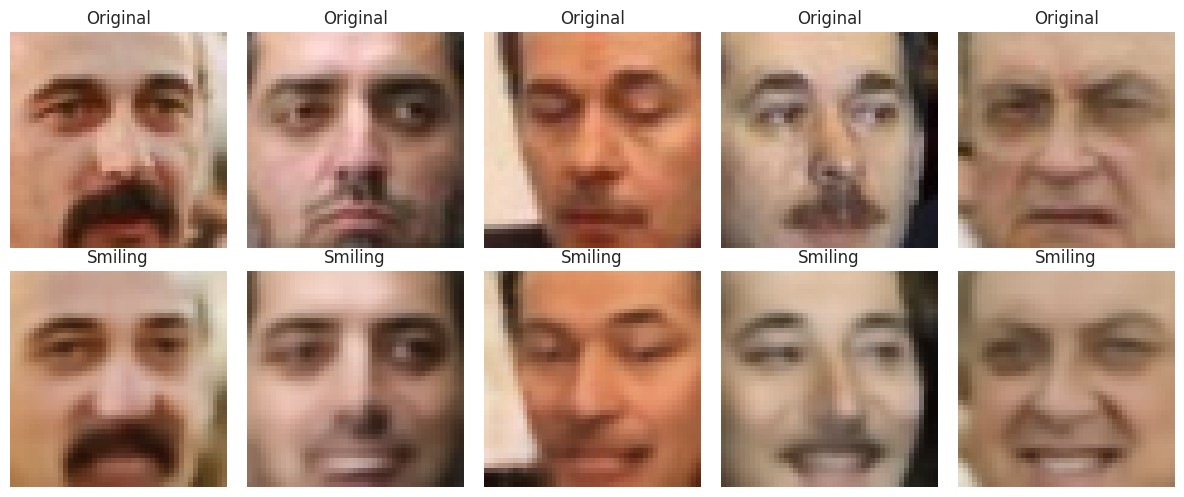

In [ ]:
diff = mean['smiling'] - mean['frowning']
latents, origs = [], []
n_images = 15

model.eval()
with torch.no_grad():
    for X_batch in frowning_loader:
        X_batch = X_batch.to(device)
        reconstructed, latent_code = model(X_batch)
        origs.append(X_batch.cpu())
        latents.append(latent_code.cpu())

origs = torch.cat(origs, dim=0)
z_new = torch.cat(latents, dim=0) + diff

model.eval()
with torch.no_grad():
    x = model.from_latent(z_new.to(device))
    x = x.view(-1, 128, 6, 6)
    generated = model.decoder(x).cpu()

plt.figure(figsize=(12, 5))

for i in range(5):
    plt.subplot(2, 5, i + 1)
    img = origs[i].permute(1, 2, 0)
    img = torch.clamp(img, 0, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 5, i + 6)
    img = generated[i].permute(1, 2, 0)
    img = torch.clamp(img, 0, 1)
    plt.imshow(img)
    plt.title("Smiling")
    plt.axis("off")

plt.tight_layout()
plt.show()

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

## 2.0 Загружаем данные

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

Для удобства напишем свой класс OnlyImages, с помощью которого из (image, label) сделаем просто image.

In [ ]:
from torch.utils.data import Dataset

class OnlyImages(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx][0]

In [ ]:
batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

train_dataset = OnlyImages(train_dataset)
test_dataset = OnlyImages(test_dataset)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре :) Экспериментируйте!

In [ ]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),   # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 14 -> 7
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), # 7 -> 4
            nn.ReLU(),
            nn.Flatten() # 128 * 4 * 4
        )

        self.fc_mu = nn.Linear(128 * 4 * 4, dim_code)
        self.fc_logvar = nn.Linear(128 * 4 * 4, dim_code)

        self.from_latent = nn.Linear(dim_code, 128 * 4 * 4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1), # 4 -> 7
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), # 7 -> 14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),  # 14 -> 28
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        logsigma = 0.5 * logvar

        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            # засемплируйте латентный вектор из нормального распределения с параметрами mu и sigma
            std = logsigma.exp()
            eps = torch.randn_like(std)
            sample = mu + eps * std
            return sample

        # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный - mu.
        # на инференсе выход автоэнкодера должен быть детерминирован.
        return mu

    def decode(self, z):
        x = self.from_latent(z)
        x = x.view(-1, 128, 4, 4)
        reconstruction = self.decoder(x)

        return reconstruction

    def forward(self, x):
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z)

        return mu, logsigma, reconstruction

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [13]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    loss = -0.5 * torch.sum(1 + 2 * logsigma - mu.pow(2) - logsigma.exp().pow(2))
    return loss

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    loss = nn.BCELoss(reduction='sum')
    return loss(reconstruction, x)

def loss_vae(x, mu, logsigma, reconstruction):
    return KL_divergence(mu, logsigma) + log_likelihood(x, reconstruction)

Подправим наши функции для обучения модели.

In [ ]:
def train_one_epoch(train_loader, model, optimizer, criterion):
    model.train()
    train_losses_per_epoch = []

    for X_batch in train_loader:
        X_batch = X_batch.to(device)

        optimizer.zero_grad()
        mu, logsigma, reconstructed = model(X_batch)
        loss = criterion(X_batch, mu, logsigma, reconstructed)
        loss.backward()
        optimizer.step()
        train_losses_per_epoch.append(loss.item())

    return np.mean(train_losses_per_epoch)

def val_one_epoch(val_loader, model, criterion):
    model.eval()
    val_losses_per_epoch = []
    with torch.no_grad():
      for X_batch in val_loader:
        X_batch = X_batch.to(device)
        mu, logsigma, reconstructed = model(X_batch)
        loss = criterion(X_batch, mu, logsigma, reconstructed)
        val_losses_per_epoch.append(loss.item())

    return np.mean(val_losses_per_epoch)

def show_reconstructions(model, val_loader, device, n_images=5):
    model.eval()

    with torch.no_grad():
      X_batch = next(iter(val_loader))
      mu, logsigma, reconstructed = model(X_batch.to(device))

    X_batch  = X_batch.to('cpu')
    reconstructed = reconstructed.to('cpu')
    plt.figure(figsize=(n_images * 2, 4))
    for i in range(n_images):
        # оригинал
        plt.subplot(2, n_images, i + 1)
        img = X_batch[i].permute(1, 2, 0)
        plt.imshow(img)
        plt.title("Original")
        plt.axis("off")

        # реконструкция
        plt.subplot(2, n_images, i + 1 + n_images)
        img_rec = reconstructed[i].permute(1, 2, 0)
        plt.imshow(img_rec)
        plt.title("Reconstructed")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

И обучим модель:

In [ ]:
dim_code = 128

criterion = loss_vae
vae = VAE().to(device)
optimizer = torch.optim.AdamW(vae.parameters(), lr=0.001)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1/20 | train loss: 4387.2693 | val loss: 3151.9516
Epoch 2/20 | train loss: 3496.7645 | val loss: 3065.2223
Epoch 3/20 | train loss: 3405.2135 | val loss: 3002.3554
Epoch 4/20 | train loss: 3358.9394 | val loss: 2981.4833
Epoch 5/20 | train loss: 3327.9721 | val loss: 2940.2076


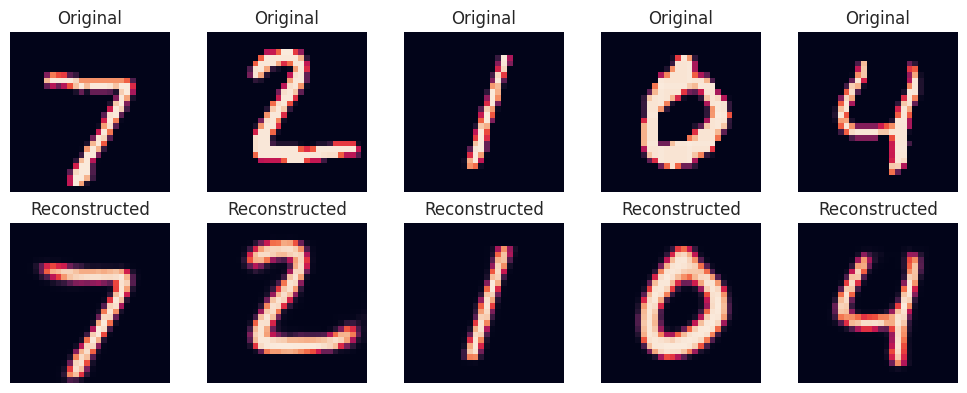

Epoch 6/20 | train loss: 3306.5325 | val loss: 2944.6326
Epoch 7/20 | train loss: 3288.2806 | val loss: 2913.1632
Epoch 8/20 | train loss: 3273.9799 | val loss: 2919.0809
Epoch 9/20 | train loss: 3261.9005 | val loss: 2906.5136
Epoch 10/20 | train loss: 3251.2427 | val loss: 2904.9311


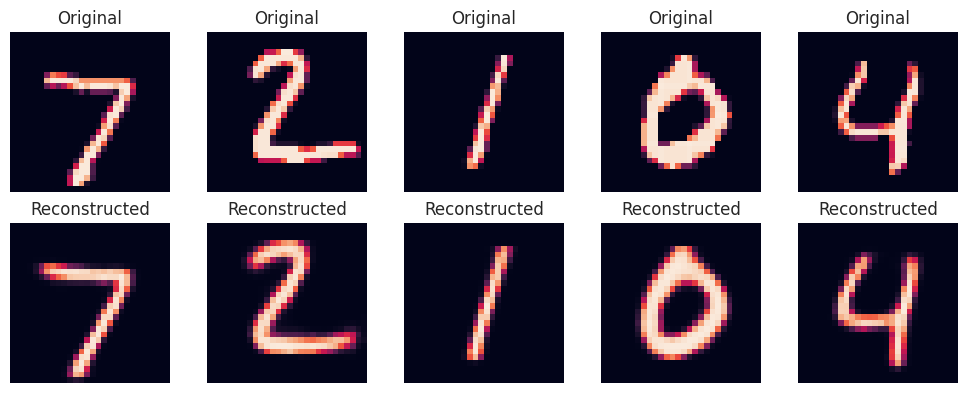

Epoch 11/20 | train loss: 3242.5331 | val loss: 2884.4216
Epoch 12/20 | train loss: 3234.2478 | val loss: 2879.4807
Epoch 13/20 | train loss: 3227.9261 | val loss: 2901.0336
Epoch 14/20 | train loss: 3219.8558 | val loss: 2904.6591
Epoch 15/20 | train loss: 3215.3077 | val loss: 2881.4037


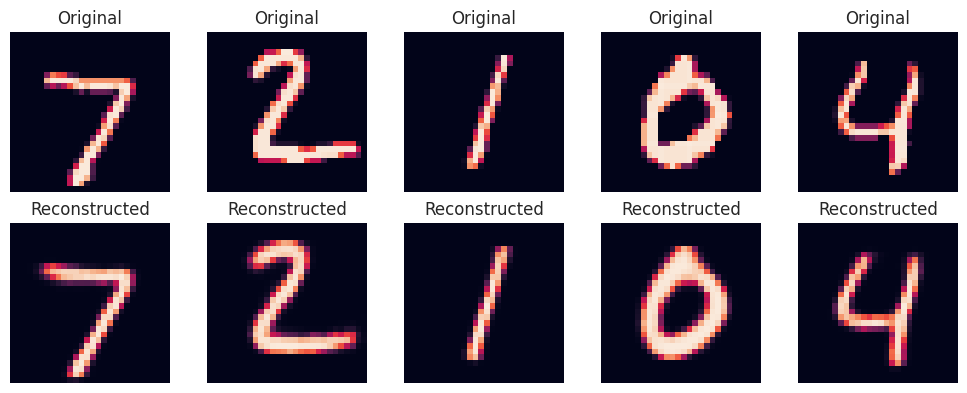

Epoch 16/20 | train loss: 3209.3479 | val loss: 2863.1011
Epoch 17/20 | train loss: 3203.6925 | val loss: 2875.5801
Epoch 18/20 | train loss: 3201.4750 | val loss: 2875.3034
Epoch 19/20 | train loss: 3194.4284 | val loss: 2880.8857
Epoch 20/20 | train loss: 3190.9478 | val loss: 2863.6307


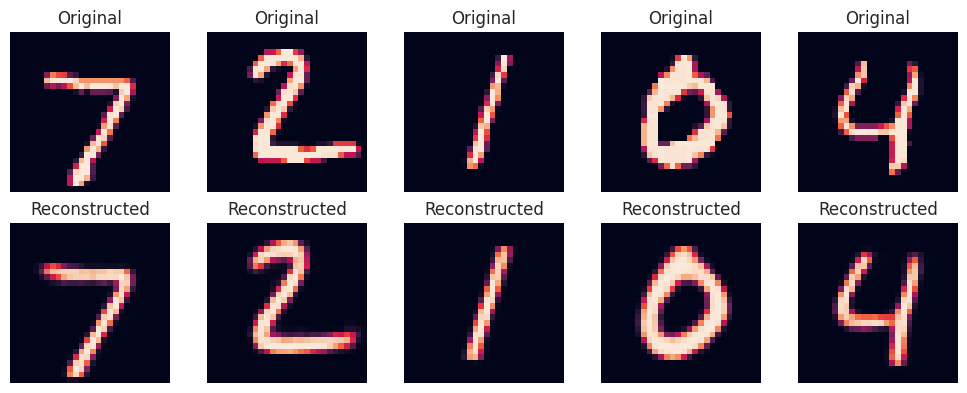

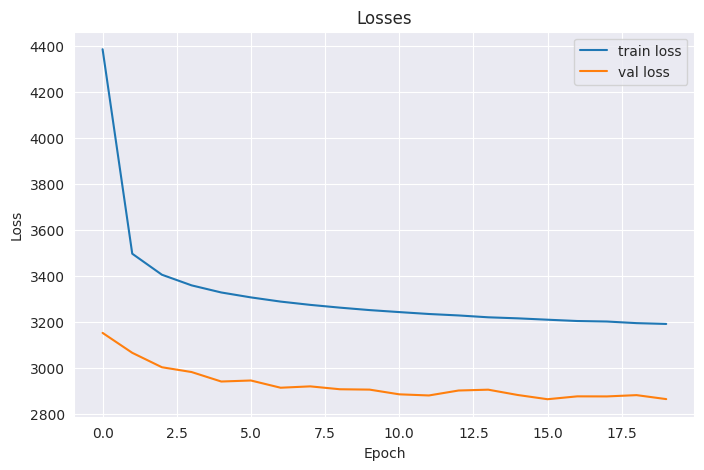

In [ ]:
train_losses, val_losses = train(vae, optimizer, criterion, train_loader, test_loader)

Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

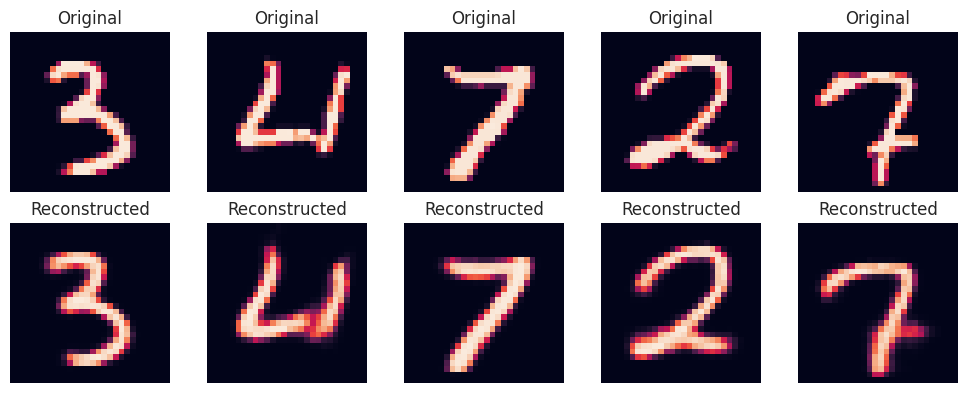

In [ ]:
from itertools import islice # для отрисовки 2-го батча (1-й был до этого)

show_reconstructions(vae, islice(test_loader, 1, None), device)

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером - подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

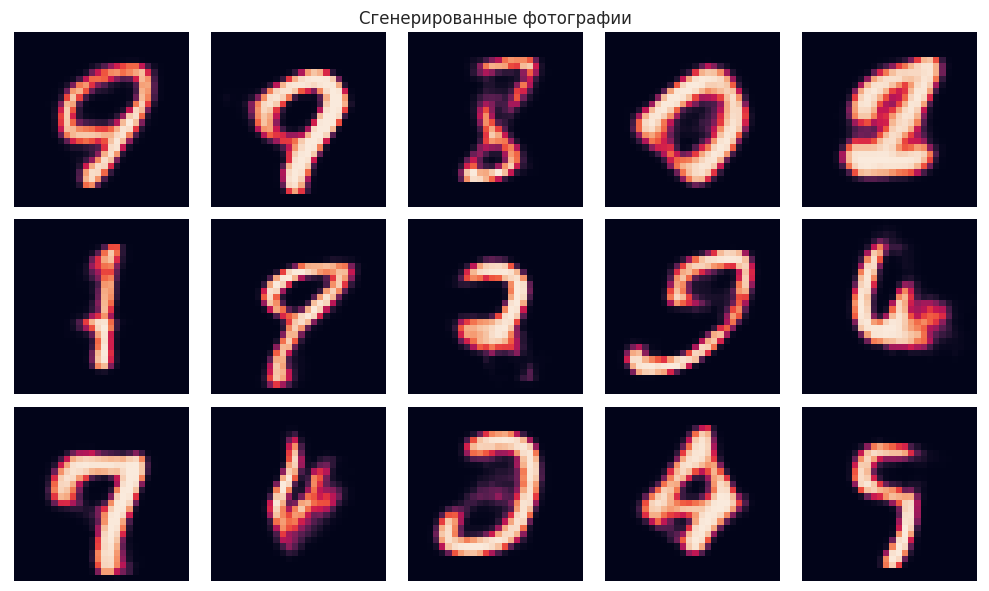

In [ ]:
# вспомните про замечание из этого же пункта обычного AE про распределение латентных переменных
n_images = 15
latents = []

vae.eval()
with torch.no_grad():
    for X_batch in test_loader:
        X_batch = X_batch.to(device)
        mu, logsigma, reconstructed = vae(X_batch)
        z = vae.gaussian_sampler(mu, logsigma)
        latents.append(z.cpu())

latents = torch.cat(latents, dim=0)
mean = latents.mean(dim=0) # mean по каждой координате в латентном векторе
std = latents.std(dim=0) # аналогично std

z_new = mean + std * torch.randn(n_images, dim_code)

vae.eval()
with torch.no_grad():
    generated = vae.decode(z_new.to(device)).cpu()

plt.figure(figsize=(5 * 2, 3 * 2))
plt.title('Сгенерированные фотографии')
plt.axis("off")
for i in range(n_images):
    plt.subplot(3, 5, i + 1)
    img = generated[i].permute(1, 2, 0)
    img = torch.clamp(img, 0, 1)
    plt.imshow(img)
    plt.axis("off")
plt.tight_layout()
plt.show()

Вывод: качество генерации среднее, часть цифр искажены и неклассифицируемы.

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

Получим латентные вектора с соответствующими labels.

In [ ]:
# MNIST Dataset
test_labels_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
test_labels_loader = torch.utils.data.DataLoader(dataset=test_labels_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
latents, labels = [], []

vae.eval()
with torch.no_grad():
  for X_batch, y_batch in test_labels_loader:
      X_batch = X_batch.to(device)
      mu, logsigma, reconstructed = vae(X_batch)
      z = vae.gaussian_sampler(mu, logsigma)

      latents.append(z.cpu())
      labels.append(y_batch)

latents = torch.cat(latents, dim=0).numpy()[:5000]
labels = torch.cat(labels, dim=0).numpy()[:5000]

Сожмём наши latents c dim_code = 128 до размерности 2 и визуализируем.

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=21)
latents_2d = tsne.fit_transform(latents)

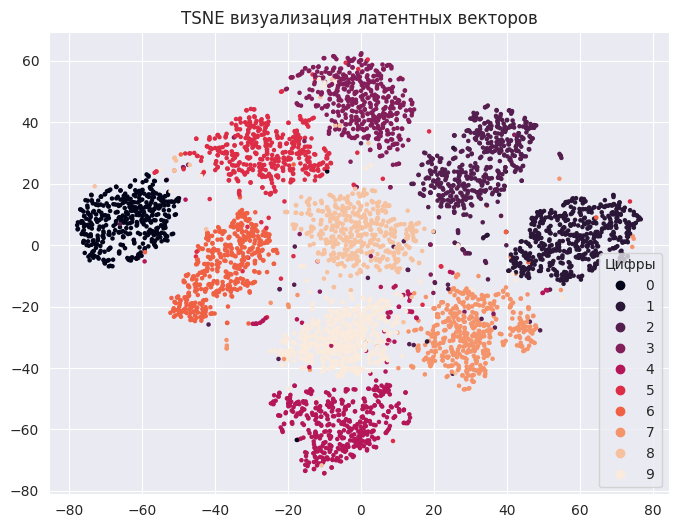

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels, s=5)
plt.title("TSNE визуализация латентных векторов")
plt.legend(*scatter.legend_elements(), title="Цифры")
plt.show()

Что вы думаете о виде латентного представления?

Вывод: VAE хорошо разложил объекты в латентном пространстве. На графике видно, что похожие объекты находятся рядом и образуют группы. Разделение неидеальное, но в целом модель справилась достаточно хорошо.

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного - это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [ ]:
class CVAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),   # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 14 -> 7
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), # 7 -> 4
            nn.ReLU(),
            nn.Flatten() # 128 * 4 * 4
        )

        self.fc_mu = nn.Linear(128 * 4 * 4, dim_code)
        self.fc_logvar = nn.Linear(128 * 4 * 4, dim_code)

        self.from_latent = nn.Linear(dim_code + 10, 128 * 4 * 4) # будем подавать z + labels
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1), # 4 -> 7
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), # 7 -> 14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),  # 14 -> 28
            nn.Sigmoid()
        )

    def make_one_hot(self, labels):
        return F.one_hot(labels, num_classes=10).float()

    def encode(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        logsigma = 0.5 * logvar

        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            # засемплируйте латентный вектор из нормального распределения с параметрами mu и sigma
            std = logsigma.exp()
            eps = torch.randn_like(std)
            sample = mu + eps * std
            return sample

        # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный - mu.
        # на инференсе выход автоэнкодера должен быть детерминирован.
        return mu

    def decode(self, z, labels):
        labels_one_hot = self.make_one_hot(labels).to(device) # переводим наш label в вектор
        z_cond = torch.cat([z, labels_one_hot], dim=1) # конкатенируем

        x = self.from_latent(z_cond)
        x = x.view(-1, 128, 4, 4)
        reconstruction = self.decoder(x)

        return reconstruction

    def forward(self, x, labels):
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z, labels)

        return mu, logsigma, reconstruction

Обучим нашу модель.

In [ ]:
batch_size = 32

train_labels_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_labels_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_labels_loader = torch.utils.data.DataLoader(dataset=train_labels_dataset, batch_size=batch_size, shuffle=True)
test_labels_loader = torch.utils.data.DataLoader(dataset=test_labels_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
dim_code = 128

criterion = loss_vae
сvae = CVAE().to(device)
optimizer = torch.optim.AdamW(сvae.parameters(), lr=0.001)

In [ ]:
def train_one_epoch(train_loader, model, optimizer, criterion):
    model.train()
    train_losses_per_epoch = []

    for (X_batch, y_batch) in train_loader:
        X_batch = X_batch.to(device)
        optimizer.zero_grad()
        mu, logsigma, reconstructed = model(X_batch, y_batch)
        loss = criterion(X_batch, mu, logsigma, reconstructed)
        loss.backward()
        optimizer.step()
        train_losses_per_epoch.append(loss.item())

    return np.mean(train_losses_per_epoch)

def val_one_epoch(val_loader, model, criterion):
    model.eval()
    val_losses_per_epoch = []
    with torch.no_grad():
      for (X_batch, y_batch) in val_loader:
        X_batch = X_batch.to(device)
        mu, logsigma, reconstructed = model(X_batch, y_batch)
        loss = criterion(X_batch, mu, logsigma, reconstructed)
        val_losses_per_epoch.append(loss.item())

    return np.mean(val_losses_per_epoch)

def show_reconstructions(model, val_loader, device, n_images=5):
    model.eval()

    with torch.no_grad():
      X_batch, y_batch = next(iter(val_loader))
      mu, logsigma, reconstructed = model(X_batch.to(device), y_batch)

    X_batch  = X_batch.to('cpu')
    reconstructed = reconstructed.to('cpu')
    plt.figure(figsize=(n_images * 2, 4))
    for i in range(n_images):
        # оригинал
        plt.subplot(2, n_images, i + 1)
        img = X_batch[i].permute(1, 2, 0)
        plt.imshow(img)
        plt.title("Original")
        plt.axis("off")

        # реконструкция
        plt.subplot(2, n_images, i + 1 + n_images)
        img_rec = reconstructed[i].permute(1, 2, 0)
        plt.imshow(img_rec)
        plt.title("Reconstructed")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1/20 | train loss: 4276.0712 | val loss: 3126.9437
Epoch 2/20 | train loss: 3438.0165 | val loss: 2971.2177
Epoch 3/20 | train loss: 3344.7929 | val loss: 2934.6885
Epoch 4/20 | train loss: 3292.3313 | val loss: 2934.9004
Epoch 5/20 | train loss: 3257.7822 | val loss: 2900.3396


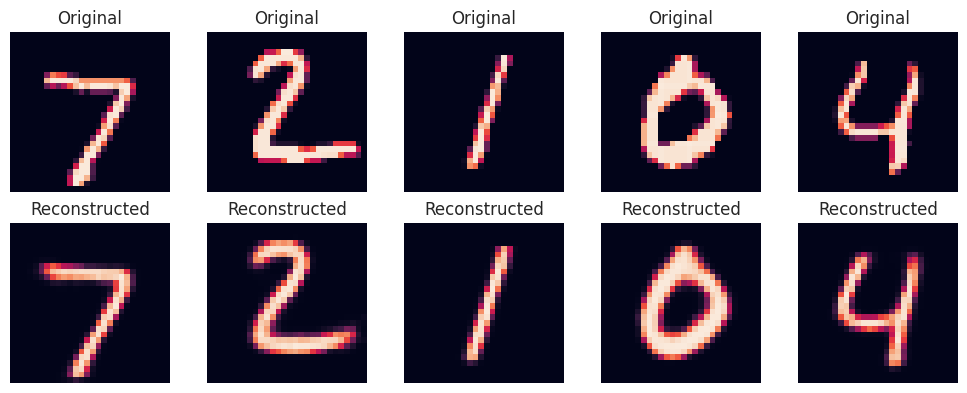

Epoch 6/20 | train loss: 3229.4690 | val loss: 2916.3459
Epoch 7/20 | train loss: 3208.6386 | val loss: 2887.7386
Epoch 8/20 | train loss: 3190.2940 | val loss: 2857.5202
Epoch 9/20 | train loss: 3175.7601 | val loss: 2864.8362
Epoch 10/20 | train loss: 3161.9724 | val loss: 2852.9460


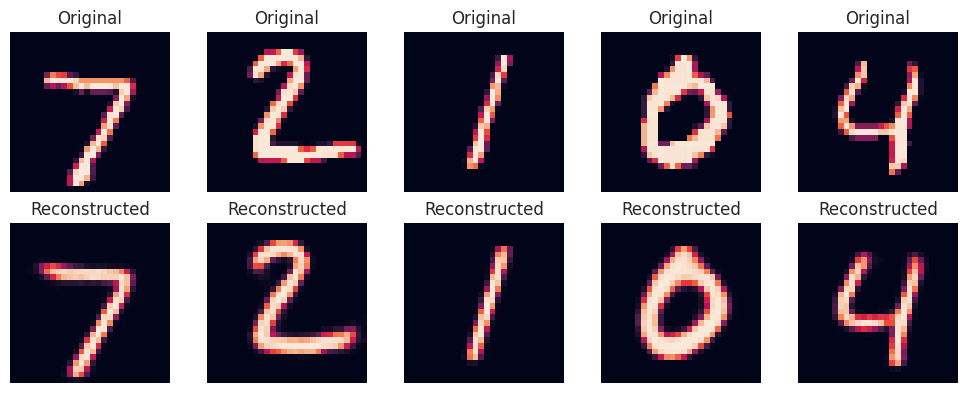

Epoch 11/20 | train loss: 3151.3946 | val loss: 2850.8655
Epoch 12/20 | train loss: 3141.5273 | val loss: 2832.8250
Epoch 13/20 | train loss: 3133.9329 | val loss: 2854.4657
Epoch 14/20 | train loss: 3124.3504 | val loss: 2816.3697
Epoch 15/20 | train loss: 3118.1314 | val loss: 2818.2167


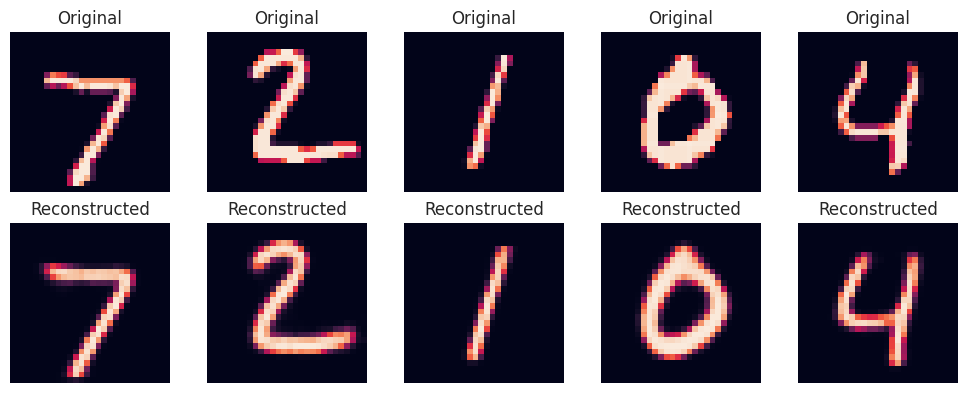

Epoch 16/20 | train loss: 3110.7868 | val loss: 2826.7825
Epoch 17/20 | train loss: 3105.0588 | val loss: 2829.1514
Epoch 18/20 | train loss: 3097.9123 | val loss: 2814.2779
Epoch 19/20 | train loss: 3096.9266 | val loss: 2796.6120
Epoch 20/20 | train loss: 3091.3552 | val loss: 2829.7210


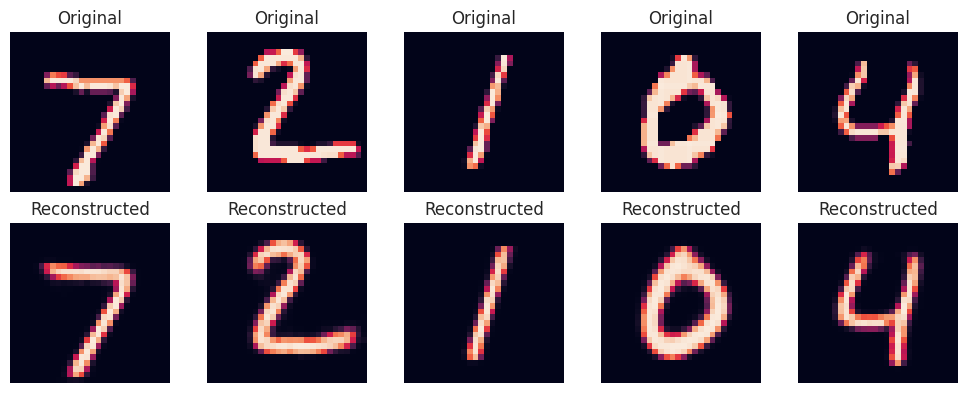

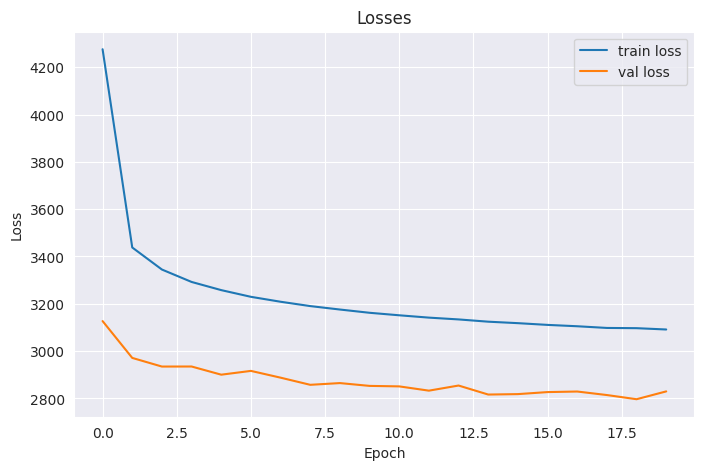

In [ ]:
train_losses, val_losses = train(сvae, optimizer, criterion, train_labels_loader, test_labels_loader)

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

Восстановим из одного латентного ветора все 10 цифр.

In [ ]:
n_images = 15
latents = []

сvae.eval()
with torch.no_grad():
  for X_batch, y_batch in test_labels_loader:
      X_batch = X_batch.to(device)
      mu, logsigma, reconstructed = сvae(X_batch, y_batch)
      z = сvae.gaussian_sampler(mu, logsigma)
      latents.append(z.cpu())

latents = torch.cat(latents, dim=0)
mean = latents.mean(dim=0) # mean по каждой координате в латентном векторе
std = latents.std(dim=0) # аналогично std

z_new = mean + std * torch.randn(n_images, dim_code)

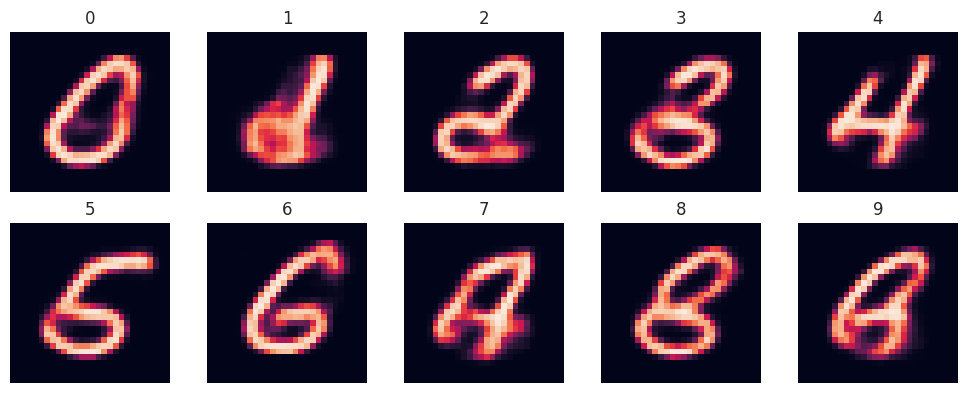

In [ ]:
z = z_new[0].unsqueeze(0)
z = z.repeat(10, 1).to(device)
labels = torch.arange(10, dtype=torch.long).to(device)

with torch.no_grad():
    generated = сvae.decode(z, labels)

generated = generated.cpu()

plt.figure(figsize=(5 * 2, 2 * 2))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = generated[i].squeeze(0)
    plt.imshow(img)
    plt.title(str(i))
    plt.axis("off")

plt.tight_layout()
plt.show()

Splendid! Вы великолепны!


Вывод: В целом, наш CVAE неплохо генерирует определённые цифры. Без искажений получились 0, 2, 4, 6, 8.

### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

In [ ]:
latents, labels = [], []

сvae.eval()
with torch.no_grad():
  for X_batch, y_batch in test_labels_loader:
      X_batch = X_batch.to(device)
      mu, logsigma, reconstructed = сvae(X_batch, y_batch)
      z = сvae.gaussian_sampler(mu, logsigma)
      latents.append(z.cpu())
      labels.append(y_batch)

latents = torch.cat(latents, dim=0).numpy()[:5000]
labels = torch.cat(labels, dim=0).numpy()[:5000]

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=21)
latents_2d = tsne.fit_transform(latents)

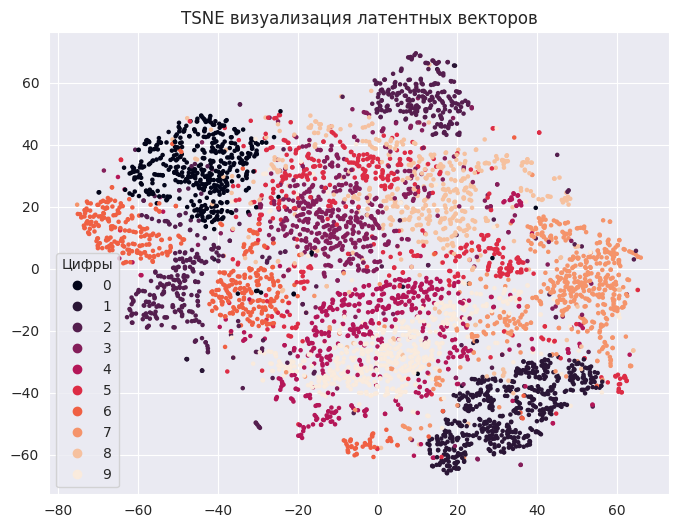

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels, s=5)
plt.title("TSNE визуализация латентных векторов")
plt.legend(*scatter.legend_elements(), title="Цифры")
plt.show()

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

Вывод: Для CVAE классы разделились на группы хуже, чем у VAE. Возможно, это связано с тем, что класс цифры передаётся отдельно через labels, поэтому latent теперь больше хранит информацию о стиле написания, чем о самой цифре.

# BONUS 1: Denoising (2 балла)



У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

Перепишем наши функции для обучения модели.

In [ ]:
def add_noise(X):
    noise_factor=0.5
    X_noisy = X + noise_factor * torch.randn_like(X)
    X_noisy = torch.clamp(X_noisy, 0.0, 1.0)
    return X_noisy

def train_one_epoch(train_loader, model, optimizer, criterion):
    model.train()
    train_losses_per_epoch = []

    for X_batch in train_loader:
        X_batch = X_batch.to(device)
        X_noisy = add_noise(X_batch) # добавляем шум
        optimizer.zero_grad()
        reconstructed, latent_code = model(X_noisy) # реконструируем на зашумлённой
        loss = criterion(reconstructed, X_batch) # лосс по оригинальной
        loss.backward()
        optimizer.step()
        train_losses_per_epoch.append(loss.item())

    return np.mean(train_losses_per_epoch)

def val_one_epoch(val_loader, model, criterion):
    model.eval()
    val_losses_per_epoch = []

    with torch.no_grad():
        for X_batch in val_loader:
            X_batch = X_batch.to(device) # добавляем шум
            X_noisy = add_noise(X_batch)
            reconstructed, latent_code = model(X_noisy) # реконструируем на зашумлённой
            loss = criterion(reconstructed, X_batch) # лосс по оригинальной
            val_losses_per_epoch.append(loss.item())

    return np.mean(val_losses_per_epoch)

def show_reconstructions(model, val_loader, device, n_images=5):
    model.eval()

    with torch.no_grad():
        X_batch = next(iter(val_loader))
        X_batch = X_batch.to(device)
        X_noisy = add_noise(X_batch)
        reconstructed, latent_code = model(X_noisy)

    X_batch = X_batch.cpu()
    X_noisy = X_noisy.cpu()
    reconstructed = reconstructed.cpu()

    plt.figure(figsize=(n_images * 2, 6))

    for i in range(n_images):
        # оригинал
        plt.subplot(3, n_images, i + 1)
        img = X_batch[i].permute(1, 2, 0)
        plt.imshow(img)
        plt.title("Original")
        plt.axis("off")

        # зашумлённая картинка
        plt.subplot(3, n_images, i + 1 + n_images)
        img_noisy = X_noisy[i].permute(1, 2, 0)
        plt.imshow(img_noisy)
        plt.title("Noisy")
        plt.axis("off")

        # восстановленная картинка
        plt.subplot(3, n_images, i + 1 + 2 * n_images)
        img_rec = reconstructed[i].permute(1, 2, 0)
        plt.imshow(img_rec)
        plt.title("Reconstructed")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
train_loader = torch.utils.data.DataLoader(train_img.permute(0,3,1,2), batch_size=5)
val_loader = torch.utils.data.DataLoader(val_img.permute(0,3,1,2), batch_size=5)

criterion = F.mse_loss
model = Autoencoder().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1/20 | train loss: 0.0116 | val loss: 0.0074
Epoch 2/20 | train loss: 0.0068 | val loss: 0.0064
Epoch 3/20 | train loss: 0.0061 | val loss: 0.0060
Epoch 4/20 | train loss: 0.0058 | val loss: 0.0057
Epoch 5/20 | train loss: 0.0056 | val loss: 0.0056


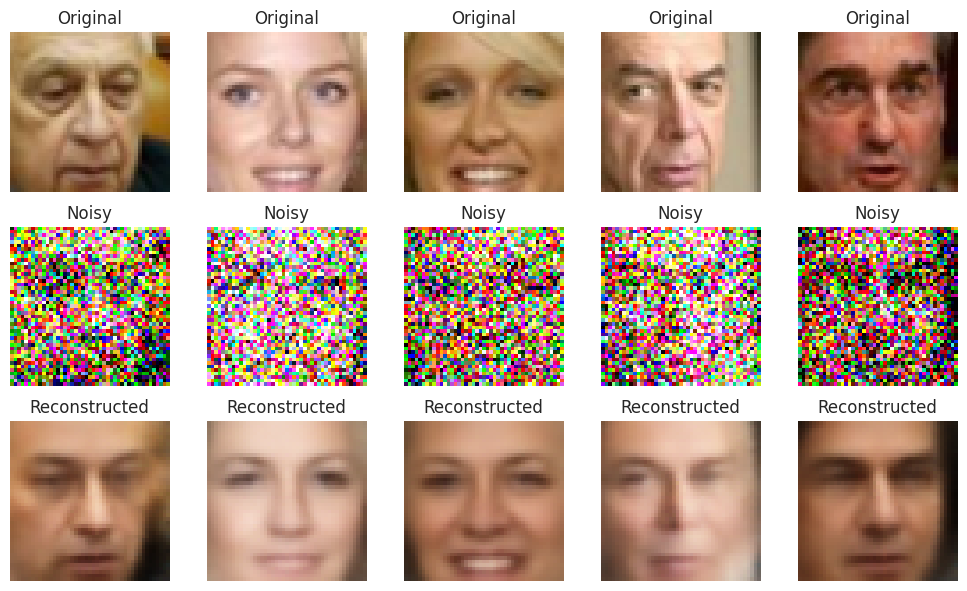

Epoch 6/20 | train loss: 0.0055 | val loss: 0.0055
Epoch 7/20 | train loss: 0.0054 | val loss: 0.0054
Epoch 8/20 | train loss: 0.0053 | val loss: 0.0053
Epoch 9/20 | train loss: 0.0052 | val loss: 0.0052
Epoch 10/20 | train loss: 0.0052 | val loss: 0.0052


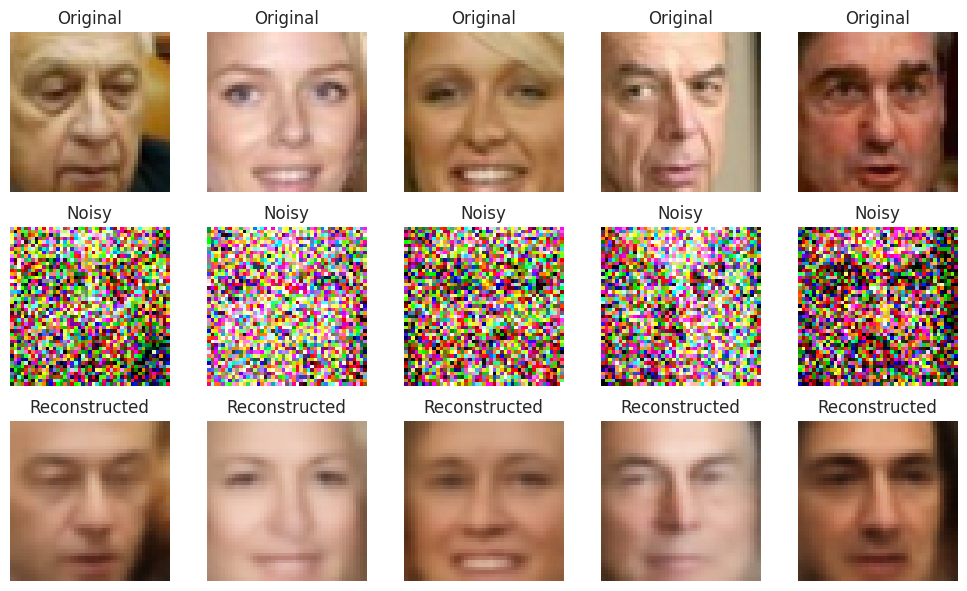

Epoch 11/20 | train loss: 0.0051 | val loss: 0.0053
Epoch 12/20 | train loss: 0.0051 | val loss: 0.0051
Epoch 13/20 | train loss: 0.0050 | val loss: 0.0051
Epoch 14/20 | train loss: 0.0050 | val loss: 0.0050
Epoch 15/20 | train loss: 0.0049 | val loss: 0.0051


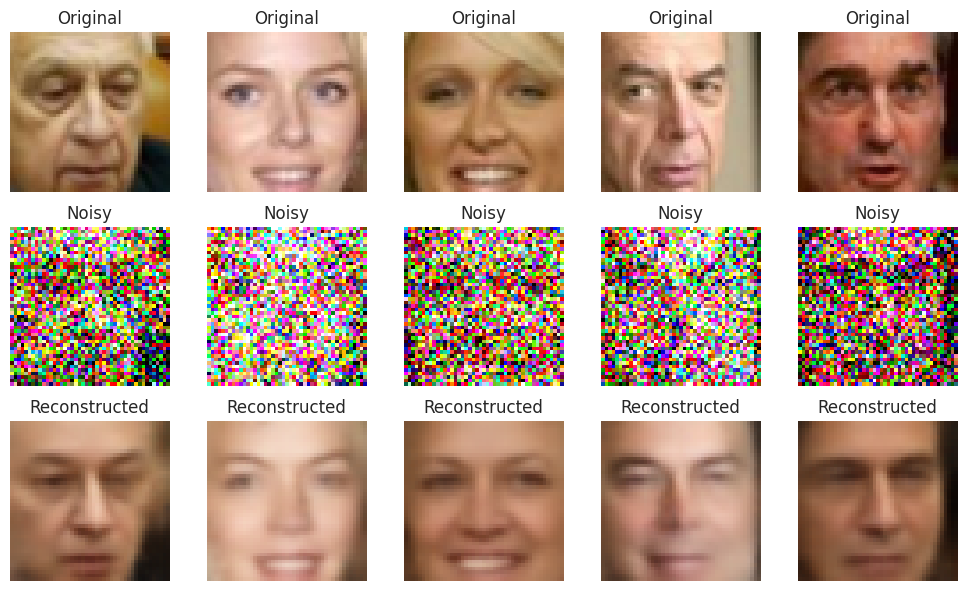

Epoch 16/20 | train loss: 0.0049 | val loss: 0.0050
Epoch 17/20 | train loss: 0.0049 | val loss: 0.0050
Epoch 18/20 | train loss: 0.0049 | val loss: 0.0050
Epoch 19/20 | train loss: 0.0048 | val loss: 0.0050
Epoch 20/20 | train loss: 0.0048 | val loss: 0.0050


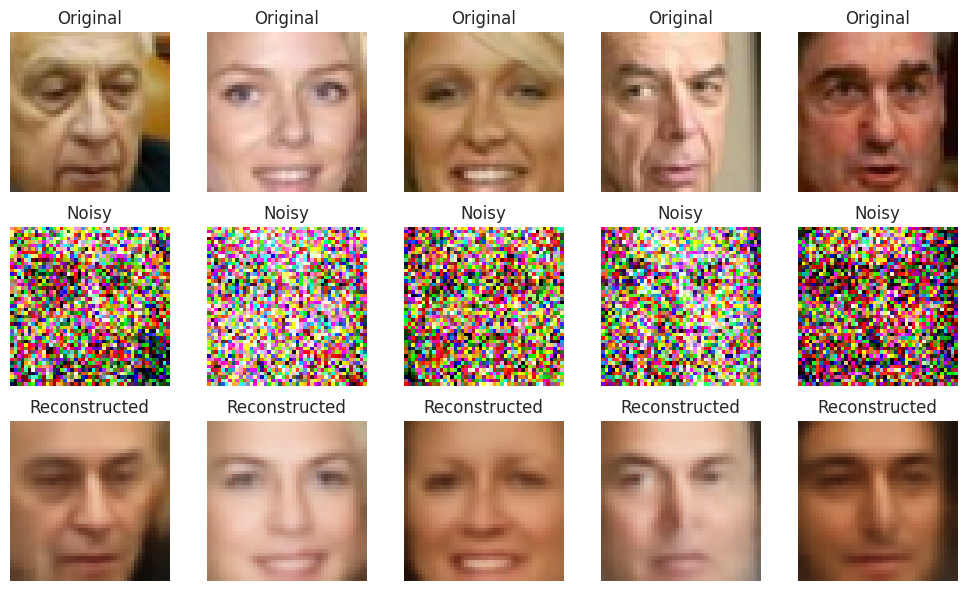

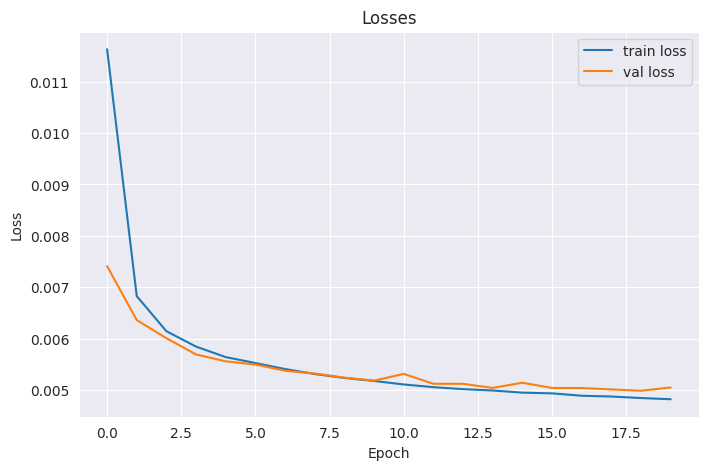

In [ ]:
train_losses, val_losses = train(model, optimizer, criterion, train_loader, val_loader)

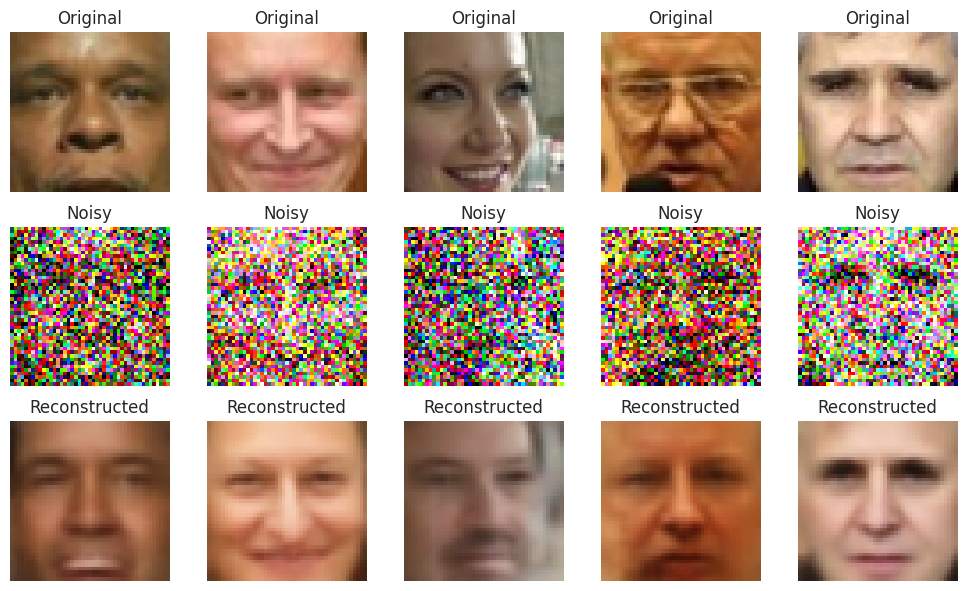

In [ ]:
from itertools import islice # для отрисовки 2-го батча (1-й был до этого)

show_reconstructions(model, islice(val_loader, 1, None), device)

# BONUS 2: Image Retrieval (2 балла)



Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Перепишем VAE под датасет фотографий и обучим его.

In [10]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),   # 45 -> 23
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 23 -> 12
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), # 12 -> 6
            nn.ReLU(),
            nn.Flatten(), # 128 * 6 * 6
        )

        self.fc_mu = nn.Linear(128 * 6 * 6, dim_code)
        self.fc_logvar = nn.Linear(128 * 6 * 6, dim_code)

        self.from_latent = nn.Linear(dim_code, 128 * 6 * 6)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), # 6 -> 12
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1), # 12 -> 23
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1),  # 23 -> 45
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        logsigma = 0.5 * logvar

        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            # засемплируйте латентный вектор из нормального распределения с параметрами mu и sigma
            std = logsigma.exp()
            eps = torch.randn_like(std)
            sample = mu + eps * std
            return sample

        # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный - mu.
        # на инференсе выход автоэнкодера должен быть детерминирован.
        return mu

    def decode(self, z):
        x = self.from_latent(z)
        x = x.view(-1, 128, 6, 6)
        reconstruction = self.decoder(x)

        return reconstruction

    def forward(self, x):
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z)

        return mu, logsigma, reconstruction

In [11]:
def train_one_epoch(train_loader, model, optimizer, criterion):
    model.train()
    train_losses_per_epoch = []

    for X_batch in train_loader:
        X_batch = X_batch.to(device)

        optimizer.zero_grad()
        mu, logsigma, reconstructed = model(X_batch)
        loss = criterion(X_batch, mu, logsigma, reconstructed)
        loss.backward()
        optimizer.step()
        train_losses_per_epoch.append(loss.item())

    return np.mean(train_losses_per_epoch)

def val_one_epoch(val_loader, model, criterion):
    model.eval()
    val_losses_per_epoch = []
    with torch.no_grad():
      for X_batch in val_loader:
        X_batch = X_batch.to(device)
        mu, logsigma, reconstructed = model(X_batch)
        loss = criterion(X_batch, mu, logsigma, reconstructed)
        val_losses_per_epoch.append(loss.item())

    return np.mean(val_losses_per_epoch)

def show_reconstructions(model, val_loader, device, n_images=5):
    model.eval()

    with torch.no_grad():
      X_batch = next(iter(val_loader))
      mu, logsigma, reconstructed = model(X_batch.to(device))

    X_batch  = X_batch.to('cpu')
    reconstructed = reconstructed.to('cpu')
    plt.figure(figsize=(n_images * 2, 4))
    for i in range(n_images):
        # оригинал
        plt.subplot(2, n_images, i + 1)
        img = X_batch[i].permute(1, 2, 0)
        plt.imshow(img)
        plt.title("Original")
        plt.axis("off")

        # реконструкция
        plt.subplot(2, n_images, i + 1 + n_images)
        img_rec = reconstructed[i].permute(1, 2, 0)
        plt.imshow(img_rec)
        plt.title("Reconstructed")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [20]:
dim_code = 128

criterion = loss_vae
vae = VAE().to(device)
optimizer = torch.optim.AdamW(vae.parameters(), lr=0.001)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 | train loss: 19095.2039 | val loss: 18783.8029
Epoch 2/10 | train loss: 18795.9865 | val loss: 18648.6291
Epoch 3/10 | train loss: 18724.2667 | val loss: 18622.8161
Epoch 4/10 | train loss: 18692.0517 | val loss: 18605.6238
Epoch 5/10 | train loss: 18674.7221 | val loss: 18591.5895


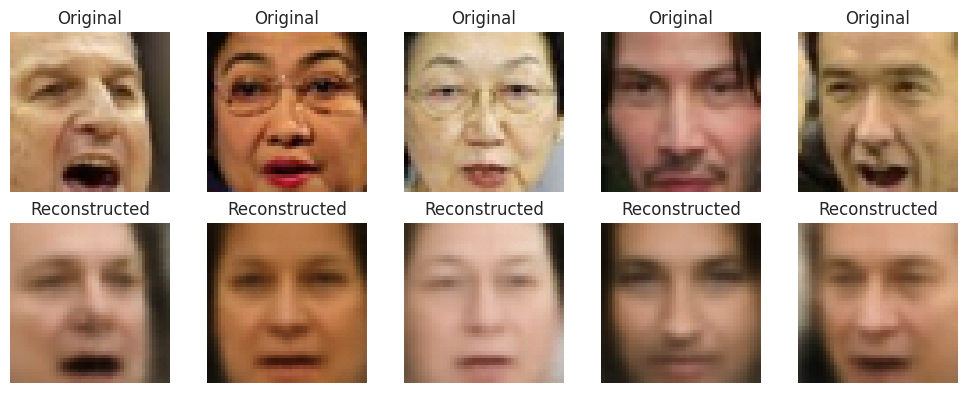

Epoch 6/10 | train loss: 18662.7251 | val loss: 18593.9190
Epoch 7/10 | train loss: 18655.6537 | val loss: 18570.1851
Epoch 8/10 | train loss: 18648.5373 | val loss: 18569.4058
Epoch 9/10 | train loss: 18643.5740 | val loss: 18559.1713
Epoch 10/10 | train loss: 18639.4648 | val loss: 18564.2766


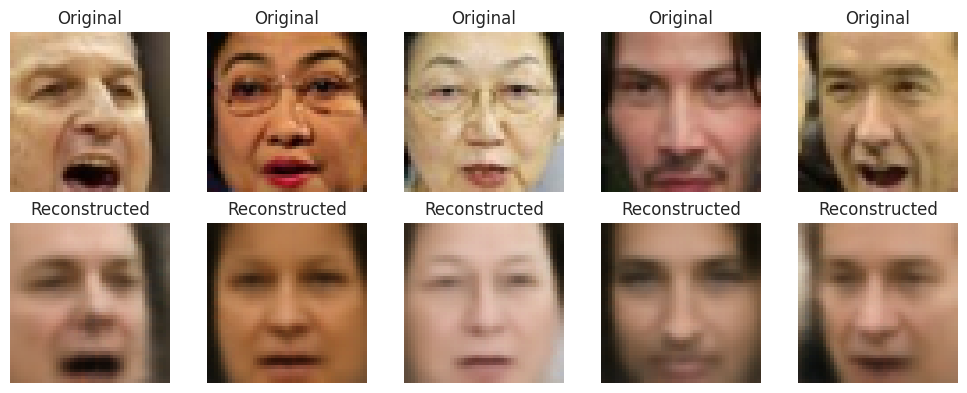

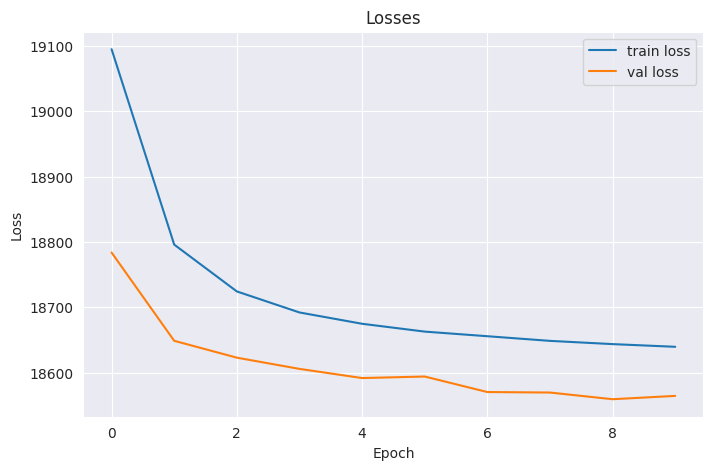

In [21]:
train_losses, val_losses = train(vae, optimizer, criterion, train_loader, val_loader, max_epochs=10)

Получим латентные представления картинок из трейна.

In [22]:
# вспомните про замечание из этого же пункта обычного AE про распределение латентных переменных
train_latents, train_images = [], []

vae.eval()
with torch.no_grad():
    for X_batch in train_loader:
        X_batch = X_batch.to(device)
        mu, logsigma, reconstructed = vae(X_batch)
        z = vae.gaussian_sampler(mu, logsigma)
        train_latents.append(z.cpu())
        train_images.append(X_batch.cpu())

train_latents = torch.cat(train_latents, dim=0).numpy()
train_images = torch.cat(train_images, dim=0)

In [23]:
# обучаем NearestNeighbors, т.к. LSHForest удалили из sklearn =(
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5)
nn.fit(train_latents)

NearestNeighbors()

In [24]:
def get_similar(image, n_neighbors=5):
  # функция, которая берет тестовый image и с помощью метода kneighbours у LSHForest ищет ближайшие векторы
  # прогоняет векторы через декодер и получает картинки ближайших людей

  vae.eval()
  with torch.no_grad():
      image = image.unsqueeze(0).to(device)
      mu, logsigma, reconstructed = vae(image)
      z = vae.gaussian_sampler(mu, logsigma)
      z = z.cpu().numpy()

  distances, idx = nn.kneighbors(z, n_neighbors=n_neighbors)

  distances = distances[0]
  idx = idx[0]

  return distances, train_images[idx]

In [25]:
def show_similar(image):
    # функция, которая принимает тестовый image, ищет ближайшие к нему и визуализирует результат

    distances, neighbors = get_similar(image, n_neighbors=11)

    plt.figure(figsize=[8,6])
    plt.subplot(3,4,1)
    plt.imshow(image.cpu().numpy().transpose([1,2,0]))
    plt.title("Original image")
    plt.axis("off")

    for i in range(11):
        plt.subplot(3,4,i+2)
        plt.imshow(neighbors[i].cpu().numpy().transpose([1,2,0]))
        plt.title("Dist=%.3f"%distances[i])
        plt.axis("off")
    plt.show()

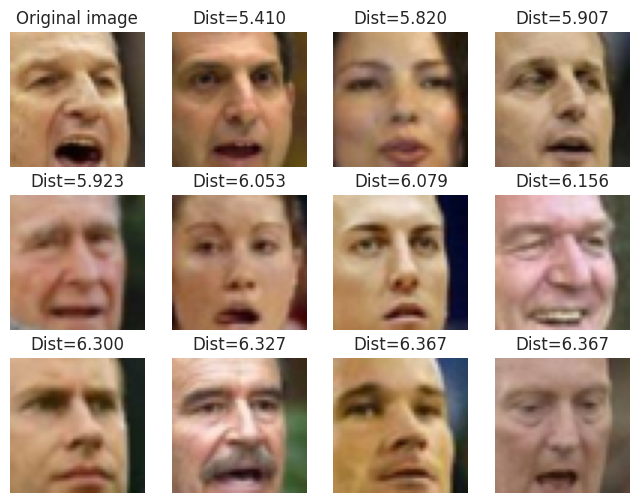

In [26]:
test_image = next(iter(val_loader))[0]
show_similar(test_image)